# Music Recommendation System

## 1. Objective

The objective of this project is to analyze a Spotify tracks dataset using **Exploratory Data Analysis (EDA)** to understand the structure, distribution, and relationships between audio features.

This analysis aims to:

- Understand key musical attributes such as **danceability, energy, valence, tempo, and loudness**
- Identify patterns and correlations between features
- Detect data quality issues such as **duplicates, missing values, and outliers**
- Explore genre distribution and dataset bias
- Prepare the dataset for **unsupervised learning techniques** such as clustering and similarity-based recommendation systems



In [47]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## 2. Dataset Overview

The dataset consists of Spotify tracks along with their audio features and metadata.


## Key Columns Description

| Feature | Type | Range / Example | Description |
|--------|------|----------------|------------|
| Unnamed: 0 | Integer | 0,1,2... | Auto-generated index |
| id | String | 5tq3Ygbw... | Unique Spotify track ID |
| name | String | Song title | Track name |
| artist | String | Artist name | Performer of the track |
| genres | String (list-like) | ['pop'] | Genre(s) of the track |
| danceability | Float | 0 – 1 | Suitability for dancing |
| energy | Float | 0 – 1 | Intensity of track |
| key | Integer | 0 – 11 | Musical key |
| loudness | Float | ~ -60 to 5 dB | Overall loudness |
| mode | Binary | 0 / 1 | Minor (0) or Major (1) |
| speechiness | Float | 0 – 1 | Spoken word presence |
| acousticness | Float | 0 – 1 | Acoustic likelihood |
| instrumentalness | Float | 0 – 1 | No vocals probability |
| liveness | Float | 0 – 1 | Live recording likelihood |
| valence | Float | 0 – 1 | Musical positivity |
| tempo | Float | ~ 50–200 BPM | Speed of track |
| type | String | audio_features | API object type |
| uri | String | spotify:track:... | Spotify URI |
| track_href | URL | API link | Track API endpoint |
| analysis_url | URL | API link | Audio analysis endpoint |
| duration_ms | Integer | e.g., 200000 | Track duration (ms) |
| time_signature | Integer | 3,4,5 | Beats per measure |
| error | Null | Mostly empty | Error field |
| popularity | Integer | 0 – 100 | Track popularity |


In [48]:
data = pd.read_csv("/content/Final Dataset.csv")
data.head()

,Unnamed: 0.1,Unnamed: 0,id,name,artist,genres,danceability,energy,key,loudness,...,valence,tempo,type,uri,track_href,analysis_url,duration_ms,time_signature,error,popularity
0,0,0.0,5tq3Ygbw8ReO3pkehrmdFH,Cumbias del pasado,Victor Bernal,['pop'],0.520,0.989,9,2.121,...,0.684,98.950,audio_features,spotify:track:5tq3Ygbw8ReO3pkehrmdFH,https://api.spotify.com/v1/tracks/5tq3Ygbw8ReO...,https://api.spotify.com/v1/audio-analysis/5tq3...,347128,4,NaN,NaN
1,1,1.0,3XGY5swlPLOmdSuMeuGxol,Babo Barish Kar De Paiso Ki,Raju Punjabi,['pop'],0.850,0.807,11,-6.950,...,0.590,117.996,audio_features,spotify:track:3XGY5swlPLOmdSuMeuGxol,https://api.spotify.com/v1/tracks/3XGY5swlPLOm...,https://api.spotify.com/v1/audio-analysis/3XGY...,272605,4,NaN,NaN
2,2,2.0,3q2cfRnoHTAhiWJgIxQvqA,Asharuwa,Mynmaster productions,['pop'],0.737,0.729,2,-9.938,...,0.940,105.092,audio_features,spotify:track:3q2cfRnoHTAhiWJgIxQvqA,https://api.spotify.com/v1/tracks/3q2cfRnoHTAh...,https://api.spotify.com/v1/audio-analysis/3q2c...,271621,4,NaN,NaN
3,3,3.0,3q2cfRnoHTAhiWJgIxQvqA,Asharuwa,Mynmaster productions,['pop'],0.737,0.729,2,-9.938,...,0.940,105.092,audio_features,spotify:track:3q2cfRnoHTAhiWJgIxQvqA,https://api.spotify.com/v1/tracks/3q2cfRnoHTAh...,https://api.spotify.com/v1/audio-analysis/3q2c...,271621,4,NaN,NaN
4,4,4.0,0O9RWQNpRlEcAaf3IEegbY,Limeryki dla odmladzajacych sie,Halina Kunicka,['pop'],0.426,0.494,11,-12.883,...,0.867,115.615,audio_features,spotify:track:0O9RWQNpRlEcAaf3IEegbY,https://api.spotify.com/v1/tracks/0O9RWQNpRlEc...,https://api.spotify.com/v1/audio-analysis/0O9R...,161991,5,NaN,NaN


### Data Overview

In [49]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6151 entries, 0 to 6150
Data columns (total 25 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0.1      6151 non-null   int64  
 1   Unnamed: 0        5114 non-null   float64
 2   id                6151 non-null   object 
 3   name              6151 non-null   object 
 4   artist            6151 non-null   object 
 5   genres            6151 non-null   object 
 6   danceability      6151 non-null   float64
 7   energy            6151 non-null   float64
 8   key               6151 non-null   int64  
 9   loudness          6151 non-null   float64
 10  mode              6151 non-null   int64  
 11  speechiness       6151 non-null   float64
 12  acousticness      6151 non-null   float64
 13  instrumentalness  6151 non-null   float64
 14  liveness          6151 non-null   float64
 15  valence           6151 non-null   float64
 16  tempo             6151 non-null   float64


In [50]:
data['type'].nunique()

1

In [51]:
data.isnull().sum()

,0
Unnamed: 0.1,0
Unnamed: 0,1037
id,0
name,0
artist,0
genres,0
danceability,0
energy,0
key,0
loudness,0


#### Insights:
- There is not much data type mismatches.
- There is lot of null values are present.
- Unnecessary columns like (Unnamed 0, Unnamed 0.1) need to be dropped.
- There are no use data columns (type, uri, track_href, analysis_url)
- There is a field having full of null values. no use case (error).
- popularity have more than 80% of null values are present.


In [52]:
data.drop(columns=['Unnamed: 0.1', 'Unnamed: 0', 'type', 'uri', 'track_href', 'analysis_url', 'error'], inplace = True)

In [53]:
data.describe(include = 'all')

,id,name,artist,genres,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature,popularity
count,6151,6151,6151,6151,6151.000000,6151.000000,6151.000000,6151.000000,6151.000000,6151.000000,6151.000000,6151.000000,6151.000000,6151.000000,6151.000000,6.151000e+03,6151.000000,1037.000000
unique,4596,4490,769,11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,024NQ7jCVO0QeUlzMeGExA,Dum Dum Karo Fareed,Nusrat Fateh Ali Khan,['ghazal'],NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,16,16,674,1263,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,0.551526,0.612281,5.205495,-8.744385,0.624451,0.080146,0.490423,0.052703,0.246756,0.604497,116.964407,4.295296e+05,3.850593,60.401157
std,NaN,NaN,NaN,NaN,0.143977,0.207051,3.450563,4.107584,0.484304,0.081371,0.314378,0.172734,0.195881,0.228793,27.932784,3.865842e+05,0.484843,18.818764
min,NaN,NaN,NaN,NaN,0.079200,0.006060,0.000000,-32.870000,0.000000,0.023700,0.000003,0.000000,0.017400,0.022100,49.613000,3.502700e+04,1.000000,0.000000
25%,NaN,NaN,NaN,NaN,0.447000,0.463500,2.000000,-10.987500,0.000000,0.037800,0.201000,0.000000,0.105000,0.427000,95.028000,2.255880e+05,4.000000,48.000000
50%,NaN,NaN,NaN,NaN,0.546000,0.628000,5.000000,-8.013000,1.000000,0.051800,0.507000,0.000022,0.169000,0.632000,113.254000,3.096310e+05,4.000000,63.000000
75%,NaN,NaN,NaN,NaN,0.661500,0.782000,8.000000,-5.833500,1.000000,0.084700,0.771000,0.002230,0.335000,0.797000,134.951000,4.565910e+05,4.000000,74.000000


### Insights :

1. Duplicate tracks present  
2. Extreme outliers in `duration_ms` and `tempo`  
3. Missing values in `popularity`  

In [54]:
data.drop_duplicates(inplace= True)

In [55]:
data[data['id'] == '0syEPhBgw69TBnLJ7NRMJn']

,id,name,artist,genres,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature,popularity
2444,0syEPhBgw69TBnLJ7NRMJn,Barishan De Mausaman Vich,Atta Ullah Khan Esakhelvi,['ghazal'],0.664,0.603,7,-9.226,1,0.0718,0.408,0.000156,0.117,0.673,158.117,410120,4,NaN
2446,0syEPhBgw69TBnLJ7NRMJn,Barishan De Mausaman Vich,Atta Ullah Khan Esakhelvi,['sufi'],0.664,0.603,7,-9.226,1,0.0718,0.408,0.000156,0.117,0.673,158.117,410120,4,NaN
4285,0syEPhBgw69TBnLJ7NRMJn,Barishan De Mausaman Vich,Atta Ullah Khan Esakhelvi,['qawwali'],0.664,0.603,7,-9.226,1,0.0718,0.408,0.000156,0.117,0.673,158.117,410120,4,NaN


In [56]:
data.describe(include = 'all')

,id,name,artist,genres,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature,popularity
count,4833,4833,4833,4833,4833.000000,4833.000000,4833.000000,4833.000000,4833.000000,4833.000000,4833.000000,4833.000000,4833.000000,4833.000000,4833.000000,4.833000e+03,4833.000000,1037.000000
unique,4596,4490,769,11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,2lfqNaJ8NrfU2cOL7UiZxd,Man Kunto Maula,Nusrat Fateh Ali Khan,Hollywood,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,3,7,446,1037,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,0.558638,0.614709,5.258845,-8.538005,0.617422,0.082872,0.473862,0.051005,0.243133,0.591168,117.128038,4.053863e+05,3.854128,60.401157
std,NaN,NaN,NaN,NaN,0.144993,0.205057,3.458756,3.998386,0.486067,0.086027,0.318761,0.170753,0.195466,0.230046,27.893546,3.592414e+05,0.481478,18.818764
min,NaN,NaN,NaN,NaN,0.079200,0.006060,0.000000,-32.870000,0.000000,0.023700,0.000003,0.000000,0.017400,0.022100,49.613000,3.502700e+04,1.000000,0.000000
25%,NaN,NaN,NaN,NaN,0.453000,0.471000,2.000000,-10.753000,0.000000,0.037900,0.167000,0.000000,0.104000,0.412000,95.705000,2.161050e+05,4.000000,48.000000
50%,NaN,NaN,NaN,NaN,0.555000,0.632000,5.000000,-7.828000,1.000000,0.052900,0.479000,0.000018,0.165000,0.613000,114.017000,2.940080e+05,4.000000,63.000000
75%,NaN,NaN,NaN,NaN,0.668000,0.779000,8.000000,-5.685000,1.000000,0.088900,0.762000,0.001710,0.330000,0.783000,134.953000,4.225890e+05,4.000000,74.000000


- Dropped the duplicate rows.
- Some id's have still duplicated id,s. because of the generes.

## 3. Univariate Analysis

#### 1. Generes

/tmp/ipykernel_1605/3107739327.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


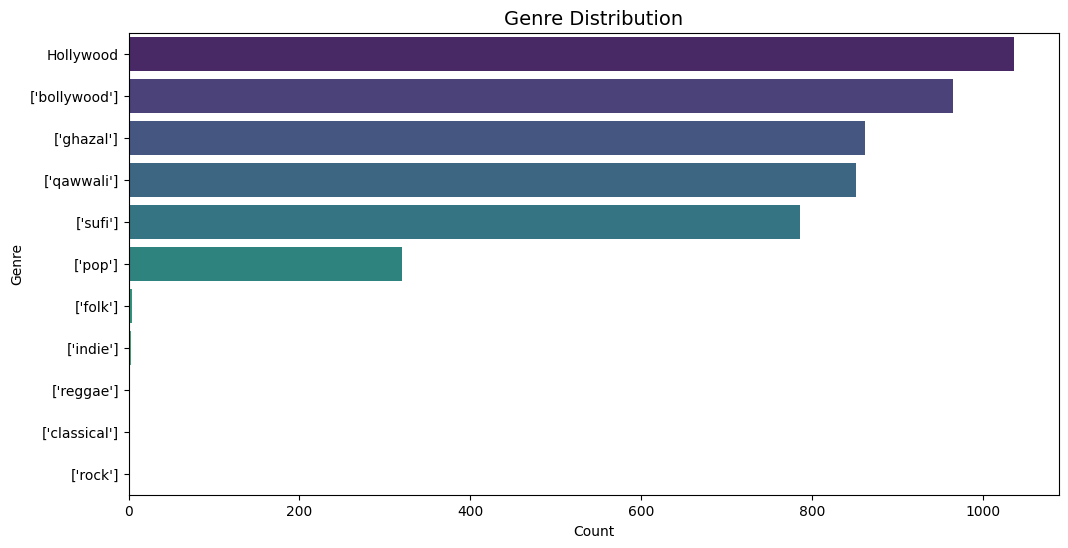

In [57]:
plt.figure(figsize=(12,6))

sns.countplot(
    data=data,
    y='genres',
    order=data['genres'].value_counts().index,
    palette='viridis'
)

plt.title("Genre Distribution", fontsize=14)
plt.xlabel("Count")
plt.ylabel("Genre")

plt.show()

### Insights

- The dataset shows a **strong imbalance**, with a few genres (Hollywood, Bollywood, Ghazal, qawwali, sufi) dominating most of the data.

- There is a clear **long-tail distribution**, where several genres (Rock, Classical, Reggae, Indie) have very few samples

- Genres are **multi-label**, meaning a single track can belong to multiple genres, not just one.

- Inconsistent genre formatting (e.g., `Hollywood` vs `['ghazal']`) indicates a **data preprocessing issue** that needs cleaning.

### Distribution Plots.


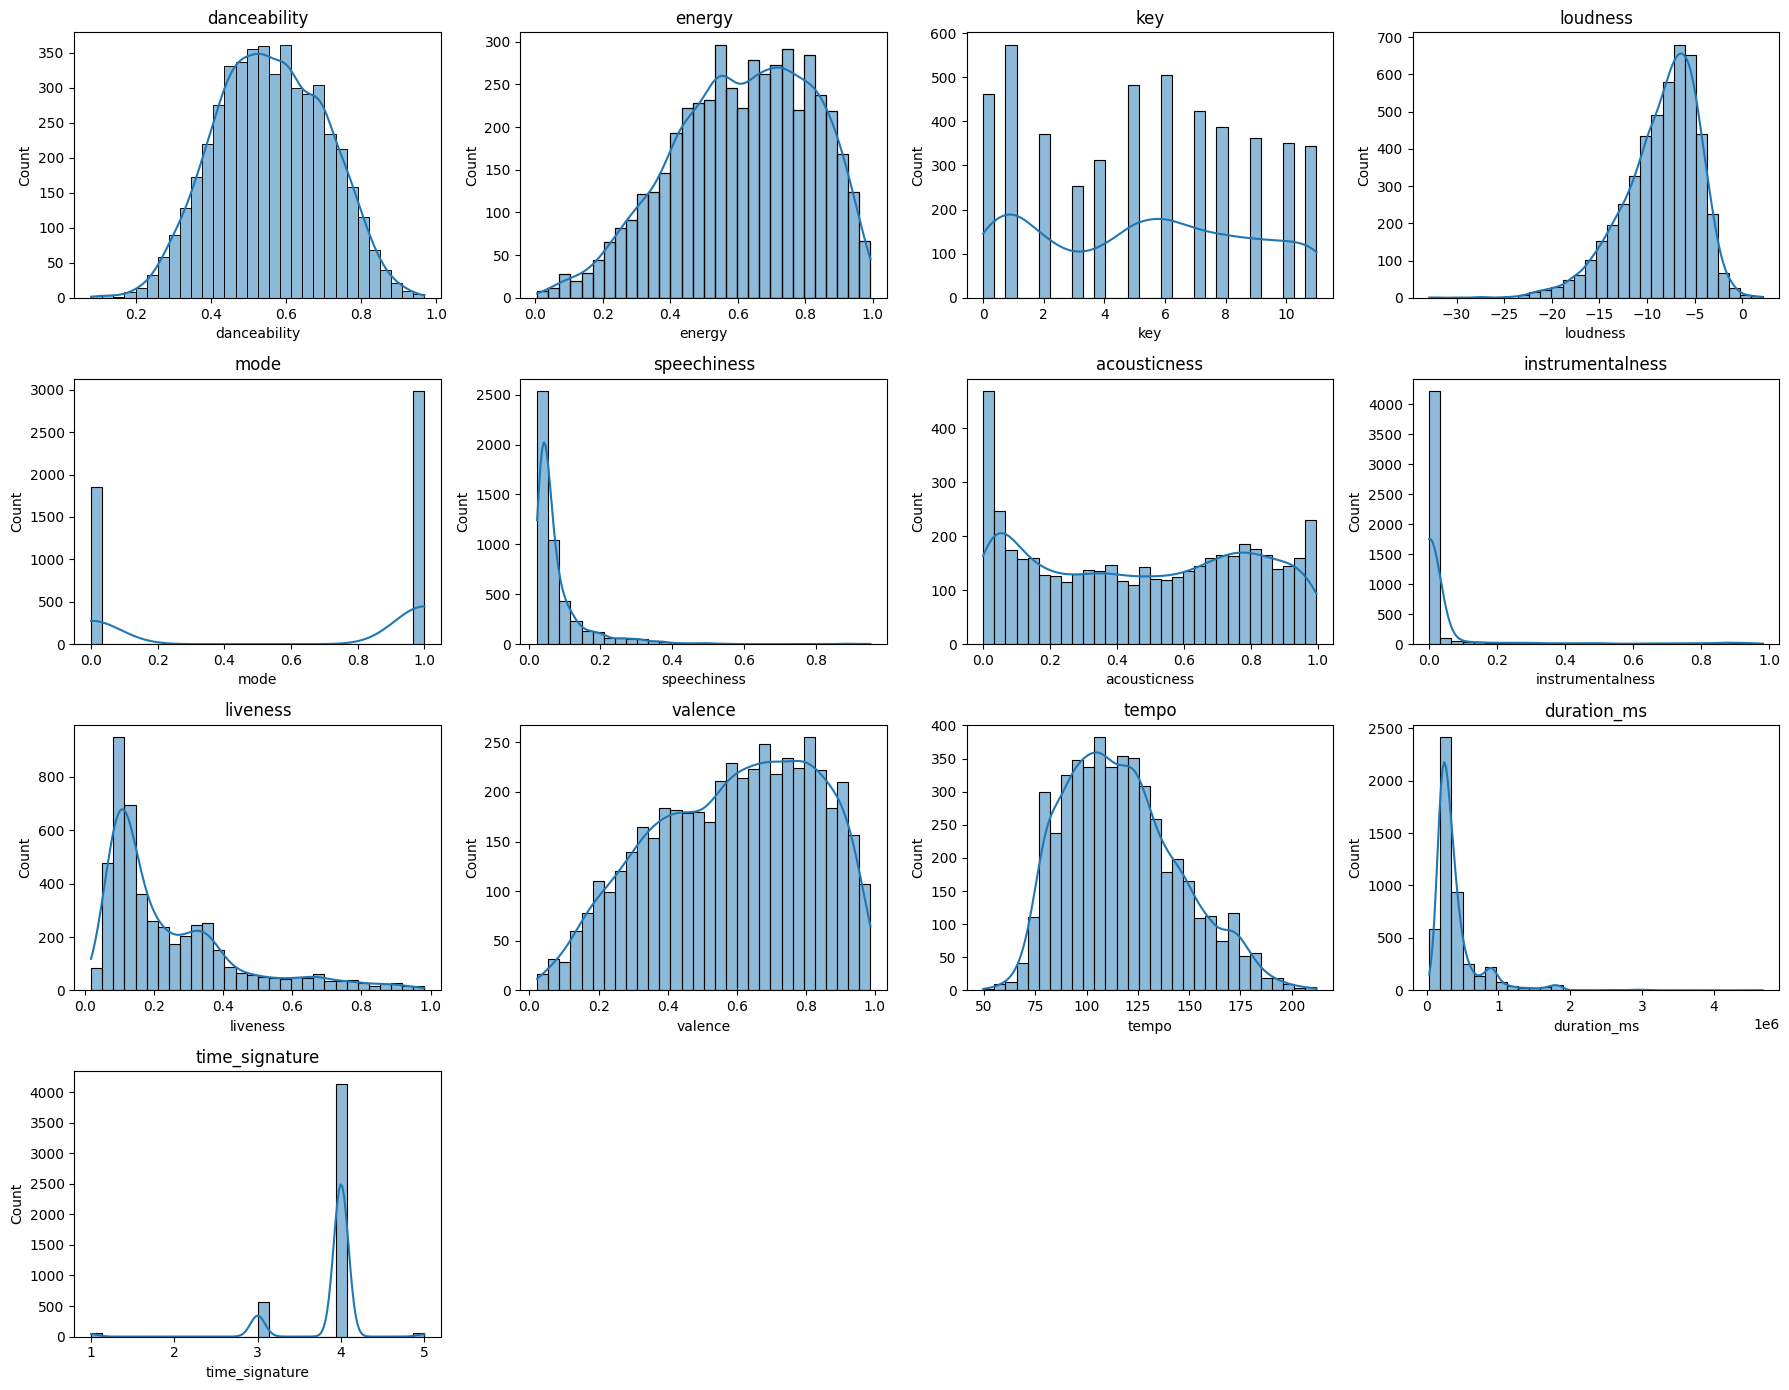

In [ ]:
num_cols = [
    'danceability','energy','key','loudness','mode',
    'speechiness','acousticness','instrumentalness',
    'liveness','valence','tempo','duration_ms',
    'time_signature'
]

plt.figure(figsize=(18, 14))

for i, col in enumerate(num_cols, 1):
    plt.subplot(4, 4, i)
    sns.histplot(data[col], kde=True, bins=30)
    plt.title(col)
    plt.tight_layout()

plt.show()

## Numerical Feature Distribution Insights

- Features like **danceability, energy, valence, and tempo** show near-normal distributions, making them well-suited for clustering.

- **Speechiness, instrumentalness, and liveness are highly right-skewed**, with most values concentrated near zero and a few extreme values.

- **Acousticness shows a wide and relatively uniform spread**, indicating a diverse mix of acoustic and electronic tracks.

- **Duration_ms contains extreme outliers**, with a long right tail representing unusually long tracks (e.g., podcasts or live recordings).

- Discrete features such as **key, mode, and time_signature show categorical distributions**, confirming they are not continuous variables.

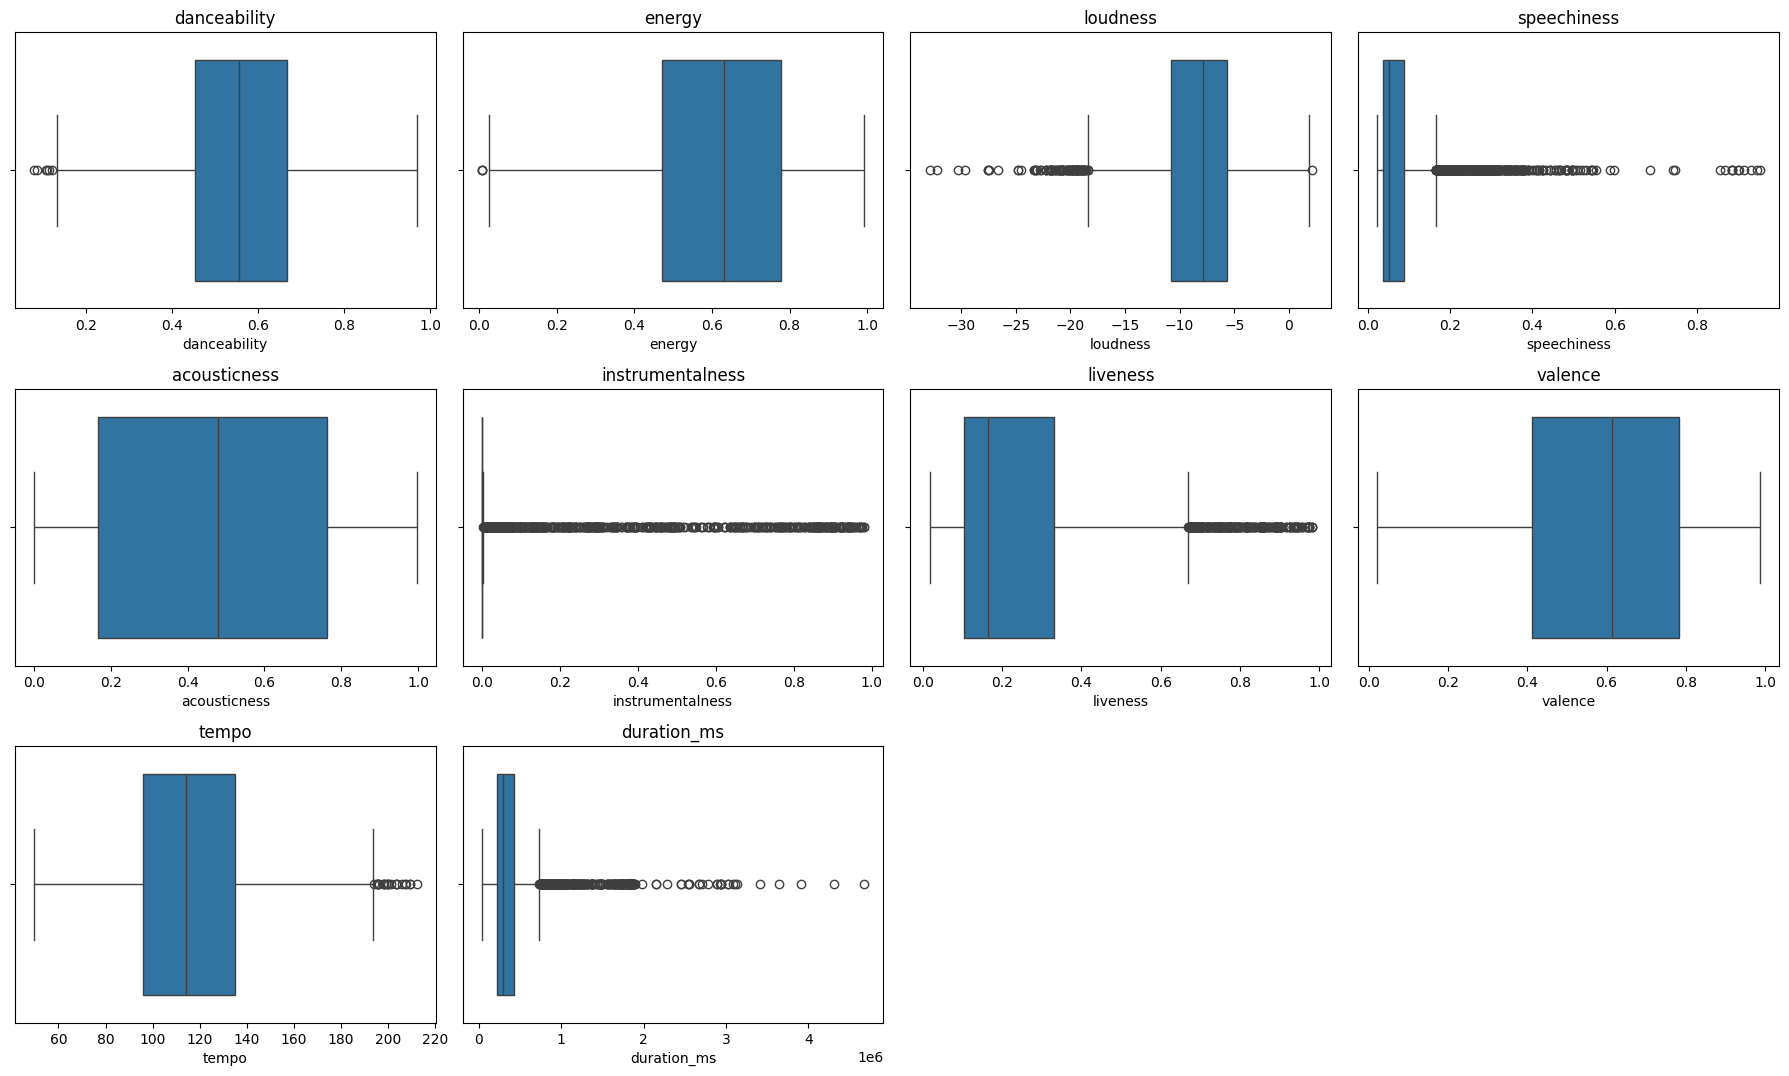

In [59]:
num_cols = [
    'danceability','energy','loudness',
    'speechiness','acousticness','instrumentalness',
    'liveness','valence','tempo','duration_ms'
    ]

plt.figure(figsize=(18, 14))

for i, col in enumerate(num_cols, 1):
    plt.subplot(4, 4, i)
    sns.boxplot(x=data[col])
    plt.title(col)

plt.tight_layout()
plt.show()

#### Insights

- **Duration_ms shows extreme right-skew with large outliers**, indicating presence of very long tracks (e.g., podcasts, live recordings, mixes).

- **Tempo contains high-value outliers**, representing unusually fast tracks that may distort similarity calculations.

- **Speechiness, instrumentalness, and liveness are highly skewed toward zero**, with few high-value points, this is a natural distribution, not noise.

- **Loudness has some lower-end outliers**, corresponding to very quiet tracks.

- **Danceability, energy, and valence are well-distributed**, with minimal extreme outliers.

- **Acousticness shows wide variability but no harmful extreme values**, indicating a balanced mix of acoustic and electronic tracks.


### 4. Multivariate analysis

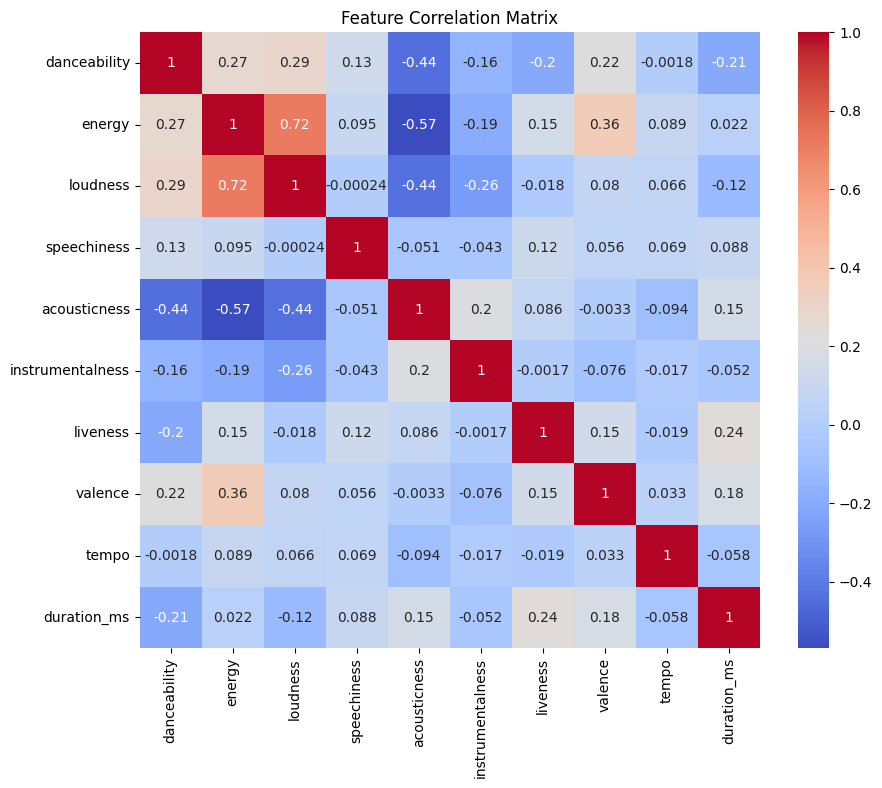

In [60]:
plt.figure(figsize=(10,8))
sns.heatmap(data[num_cols].corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Matrix")
plt.show()

#### Insights

- **Energy and loudness show strong positive correlation (~0.72)**, indicating redundancy between these features.

- **Acousticness is negatively correlated with energy (-0.57) and loudness (-0.44)**, suggesting acoustic tracks are generally less intense.

- **Danceability shows moderate correlation with energy (0.27) and valence (0.22)**, linking rhythm with positivity and intensity.

- Most other features show **weak correlations**, indicating low redundancy and diverse feature space.

- **Tempo and duration_ms have very weak correlations with other features**, meaning they add independent information.


## Conclusion

### Key Insights

- Most features (**danceability, energy, valence, tempo**) show **good distribution and variability**
- **Speechiness, instrumentalness, liveness** are highly skewed (natural behavior)
- **Duration_ms and tempo contain extreme outliers**
- **Energy and loudness are strongly correlated**, indicating partial redundancy
- Dataset shows **genre imbalance and multi-label structure**
- Feature space is **diverse with low multicollinearity**, suitable for clustering

### Data Quality Issues

- Duplicate tracks (same `id`)
- Multi-row representation due to multiple genres
- Inconsistent genre formatting
- Irrelevant API-related columns
- High missing values in `popularity`
- Presence of extreme outliers (duration, tempo)


### Preprocessing Strategy

- Remove duplicates based on `id`
- Merge multi-genre entries into a single record per track
- Drop irrelevant columns (`uri`, `track_href`, `analysis_url`, `type`, `error`)
- Drop/ignore `popularity` (insufficient data)
- Handle outliers:
  - Cap/remove extreme `duration_ms` and `tempo`
- Apply **StandardScaler** for normalization
- Select core numerical features for modeling


### Modeling Approaches

- **K-Means Clustering**, primary method for grouping similar songs  
- **Cosine Similarity**, recommendation based on feature similarity  
- **Hierarchical Clustering**, cluster structure understanding (optional)  
- **PCA**, dimensionality reduction and visualization  


### Final Pipeline

1. Data Cleaning  
2. Feature Selection  
3. Outlier Handling  
4. Feature Scaling   
5. Clustering (K-Means)  
6. Similarity Computation (KNN / Cosine)  
7. Recommendation Generation  


### Conclusion

- Dataset is **cleanable and suitable** for unsupervised learning  
- Audio features provide **strong signal for similarity-based recommendation**  
- Proper preprocessing ensures **robust clustering and meaningful recommendations**  
- A combination of **clustering + similarity models** forms an effective recommendation system  


## 4. Data Preprocessing

### Preprocessing Decisions

| Step | Action | Justification |
|------|--------|---------------|
| Drop columns | Remove uri, track_href, analysis_url, type, error | Non-analytical metadata |
| Deduplication | Keep first occurrence of duplicate generes | Avoid bias toward repeated tracks |
| Missing values | Fill  with median; audio features have none | Median preserves distribution shape |
| Outlier capping | IQR × 3.0 for all audio features | Extreme values distort cluster centroids |
| Scaling | StandardScaler (z-score) | K-Means is distance-based; scale-sensitive |


In [61]:
import pandas as pd
import numpy as np
import ast
from sklearn.preprocessing import StandardScaler

# Load Data
df = pd.read_csv("/content/Final Dataset.csv")

print("Initial Shape:", df.shape)

# Drop Useless Column
cols_to_drop = [
    "Unnamed: 0.1", "Unnamed: 0",
    "uri", "track_href", "analysis_url",
    "type", "error"
]

df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

# Remove Duplicates
df = df.drop_duplicates()

print("After removing duplicates:", df.shape)

# Handling Genres (Multi-label)
def parse_genre(x):
    try:
        return ast.literal_eval(x) if isinstance(x, str) else x
    except:
        return []

df["genres"] = df["genres"].apply(parse_genre)

# Merging One Row Per Track.
df = df.groupby("id").agg({
    "name": "first",
    "artist": "first",
    "genres": lambda x: list(set([g for sublist in x for g in sublist])),
    "danceability": "first",
    "energy": "first",
    "key": "first",
    "loudness": "first",
    "mode": "first",
    "speechiness": "first",
    "acousticness": "first",
    "instrumentalness": "first",
    "liveness": "first",
    "valence": "first",
    "tempo": "first",
    "duration_ms": "first",
    "time_signature": "first"
}).reset_index()

df["primary_genre"] = df["genres"].apply(lambda x: x[0] if len(x) > 0 else "unknown")

## Handling Missing Values

# Fill numeric missing with median
num_cols = [
    'danceability','energy','loudness','speechiness',
    'acousticness','instrumentalness','liveness',
    'valence','tempo','duration_ms'
]

for col in num_cols:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].median(), inplace=True)

# Data Type Fixing
for col in ["key", "mode", "time_signature"]:
    if col in df.columns:
        df[col] = df[col].astype(int)


Initial Shape: (6151, 25)
After removing duplicates: (4833, 18)


## Feature Engineering

In [62]:
df["energy_dance_ratio"] = df["energy"] / (df["danceability"] + 1e-5)

df["acoustic_softness"] = df["acousticness"] * (1 - df["energy"])

df["vocal_presence"] = df["speechiness"] * (1 - df["instrumentalness"])

In [63]:
from sklearn.preprocessing import MultiLabelBinarizer

mlb = MultiLabelBinarizer()
genre_encoded = mlb.fit_transform(df['genres'])

genre_df = pd.DataFrame(genre_encoded, columns=mlb.classes_, index=df.index)

In [64]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

num_features = [
    'danceability','energy','loudness','speechiness',
    'acousticness','instrumentalness','liveness',
    'valence','tempo','duration_ms','energy_dance_ratio',
    'acoustic_softness','vocal_presence'
]

cat_features = ['key','mode','time_signature']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features)
    ]
)

In [65]:
X_preprocessed = preprocessor.fit_transform(df)
feature_name = preprocessor.get_feature_names_out()
X_preprocessed = pd.DataFrame(X_preprocessed, columns = feature_name, index = df.index)

X_preprocessed = pd.concat([X_preprocessed, genre_df], axis = 1)
X_preprocessed

,num__danceability,num__energy,num__loudness,num__speechiness,num__acousticness,num__instrumentalness,num__liveness,num__valence,num__tempo,num__duration_ms,...,bollywood,classical,folk,ghazal,indie,pop,qawwali,reggae,rock,sufi
0,-1.725046,-0.334305,0.112292,-0.594736,1.225225,-0.297012,-0.742691,-0.589611,-1.170394,2.076171,...,0,0,0,1,0,0,1,0,0,0
1,-0.335648,0.762063,-0.023657,-0.376045,-0.418384,-0.297013,1.857337,0.675778,1.441361,-0.309787,...,1,0,0,0,0,0,0,0,0,0
2,0.414077,0.050642,0.271568,5.438352,-0.574918,-0.297019,0.377646,0.329096,1.814295,-0.324481,...,0,0,0,0,0,0,0,0,0,0
3,-0.308135,-0.227105,-0.424481,-0.524153,0.733708,-0.296964,1.609863,0.840452,0.163467,0.212082,...,0,0,0,1,0,0,0,0,0,0
4,1.039995,0.133479,0.804076,-0.628291,-1.461935,-0.297019,-0.824152,-1.443315,-0.691112,-0.540414,...,0,0,0,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4591,0.255878,1.317557,0.999723,-0.266121,-1.288401,-0.297019,0.522006,0.090752,-0.255551,-0.602665,...,0,0,0,0,0,0,0,0,0,0
4592,-1.002834,1.707377,1.373457,2.487763,-1.365729,-0.296994,0.480760,1.208801,-0.855862,4.079100,...,0,0,0,0,0,0,1,0,0,0
4593,1.480200,1.088537,0.735099,-0.240665,-1.458460,3.177949,-0.963872,-1.724994,0.276797,-0.544696,...,0,0,0,0,0,0,0,0,0,0
4594,-0.837757,0.888755,0.293891,-0.292734,-0.825373,-0.296829,-0.153393,1.291138,-0.617170,3.928113,...,0,0,0,0,0,0,1,0,0,1


## Diamentionality Reduction (PCA)

Due to high diamentional space (42) and possibility of redundant information. we go for pca.

In [66]:
from sklearn.decomposition import PCA

pca = PCA(n_components=0.90)
X_pca = pca.fit_transform(X_preprocessed)

print("Reduced Shape:", X_pca.shape)


Reduced Shape: (4596, 13)


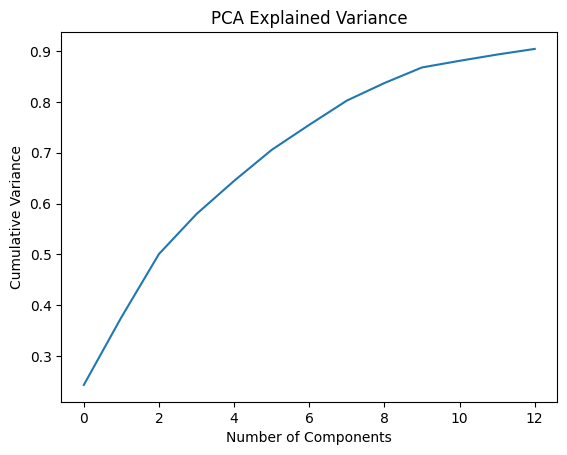

In [67]:
import matplotlib.pyplot as plt

plt.plot(pca.explained_variance_ratio_.cumsum())
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Variance")
plt.title("PCA Explained Variance")
plt.show()

## PCA Interpretation

The cumulative explained variance curve shows a steady increase without a sharp elbow, indicating that information is distributed across multiple features.

- ~90% variance is achieved with ~13 components  
- Beyond this point, additional components contribute minimal information  

Conclusion:
13 principal components were selected to balance dimensionality reduction and information retention.

In [68]:
X_pca

array([[ 1.41471394e+00, -1.91000811e-01,  2.39754259e+00, ...,
         2.89657673e-02, -3.63228365e-01,  2.49290390e-01],
       [-1.20808684e+00, -1.24232915e-01,  1.35459747e+00, ...,
         6.49488914e-01,  4.75302092e-01, -1.24124265e-01],
       [-2.14806290e+00,  6.99905073e+00, -2.33243156e+00, ...,
        -1.62712124e-01, -2.52584056e-02, -5.07535644e-01],
       ...,
       [-1.25108167e+00, -1.73948167e+00, -1.44878546e+00, ...,
         2.16432073e-01, -2.44152139e-01,  3.91795138e-01],
       [-1.53655971e+00,  4.21171210e-01,  2.76670858e+00, ...,
        -3.79096297e-01, -2.46749518e-03, -4.52995836e-01],
       [-1.07661931e-01, -8.67227609e-02,  3.29041548e+00, ...,
         8.59729645e-02, -1.85872550e-02, -3.41241914e-02]])

## Modeling

### KMeans Clustering

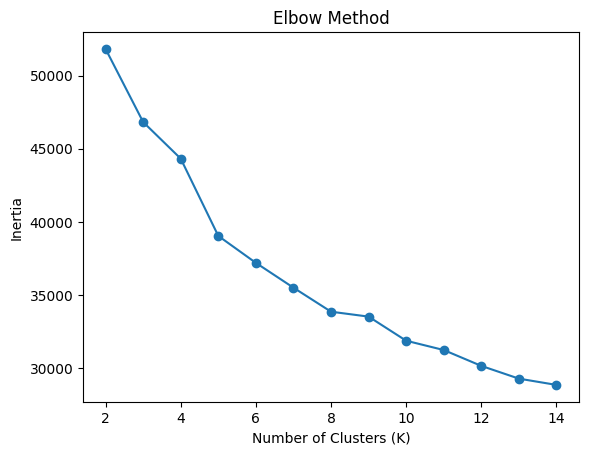

In [69]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

K_range = range(2, 15)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_pca)
    inertia.append(kmeans.inertia_)

plt.plot(K_range, inertia, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [70]:
from sklearn.metrics import silhouette_score

for k in range(2, 15):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_pca)
    score = silhouette_score(X_pca, labels)
    print(f"K={k}, Silhouette Score={score:.3f}")

K=2, Silhouette Score=0.201
K=3, Silhouette Score=0.174
K=4, Silhouette Score=0.115
K=5, Silhouette Score=0.181
K=6, Silhouette Score=0.166
K=7, Silhouette Score=0.126
K=8, Silhouette Score=0.117
K=9, Silhouette Score=0.113
K=10, Silhouette Score=0.115
K=11, Silhouette Score=0.111
K=12, Silhouette Score=0.113
K=13, Silhouette Score=0.111
K=14, Silhouette Score=0.103


## Optimal Number of Clusters

The optimal number of clusters was determined using both the Elbow Method and Silhouette Score.

- The elbow plot shows a noticeable bend around K= 4-5
- The highest silhouette score (0.181) is achieved at K=5
- Beyond this point, the score decreases, indicating poorer cluster quality

Conclusion:
K=4 was selected as the optimal number of clusters as it provides the best balance between cluster compactness and separation.

In [94]:
kmeans = KMeans(n_clusters=4, random_state=42)
df["kmeans_cluster"] = kmeans.fit_predict(X_pca)

### Hierarchical Clustering

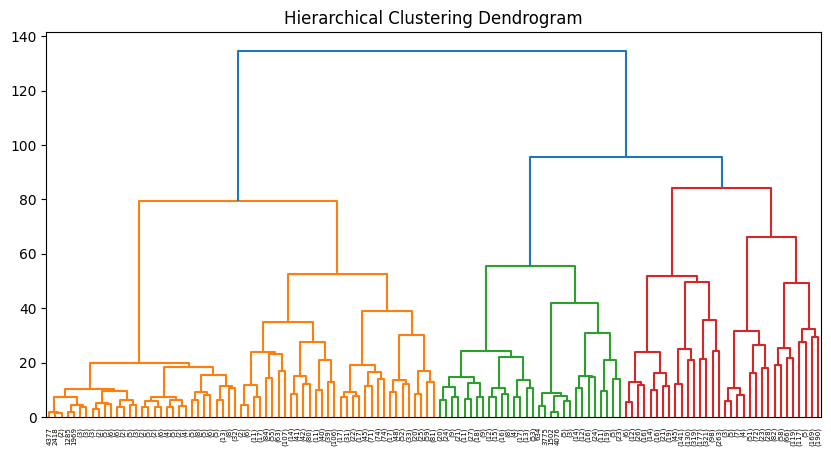

In [81]:
from scipy.cluster.hierarchy import linkage, dendrogram

linked = linkage(X_pca, method='ward')

plt.figure(figsize=(10,5))
dendrogram(linked, truncate_mode='level', p=6)
plt.title("Hierarchical Clustering Dendrogram")
plt.show()

## Hierarchical Clustering Interpretation

The dendrogram was analyzed to identify natural cluster groupings.

- A significant vertical gap was observed around distance 80 - 90
- Cutting the dendrogram at this level results in approximately 4 clusters
- This aligns with K-Means results, where K=4 showed the best silhouette score

Conclusion:
Both hierarchical clustering and K-Means suggest that 4 clusters provide the most meaningful segmentation of the data.

In [95]:
from sklearn.cluster import AgglomerativeClustering

hc = AgglomerativeClustering(n_clusters=4)
df["hierarchical_cluster"] = hc.fit_predict(X_pca)

### Cluster Evaluation

In [96]:
from sklearn.metrics import silhouette_score

print("KMeans:", silhouette_score(X_pca, df["kmeans_cluster"]))
print("Hierarchical:", silhouette_score(X_pca, df["hierarchical_cluster"]))

KMeans: 0.11524255900942812
Hierarchical: 0.11549845654362478


In [97]:
from sklearn.metrics import davies_bouldin_score

print("KMeans:", davies_bouldin_score(X_pca, df["kmeans_cluster"]))
print("Hierarchical:", davies_bouldin_score(X_pca, df["hierarchical_cluster"]))

KMeans: 2.0731013191087024
Hierarchical: 2.163922387300737


## Interpretation

Clustering performance was evaluated using Silhouette Score and Davies–Bouldin Index.

### Results:

| Model | Silhouette Score | Davies–Bouldin Index |
|------|----------------|----------------------|
| KMeans | 0.115 | 2.07 |
| Hierarchical | 0.115 | 2.16 |

### Interpretation:

- Kmeans Clustering, achieved best score, we are going for KMeans Clustering.

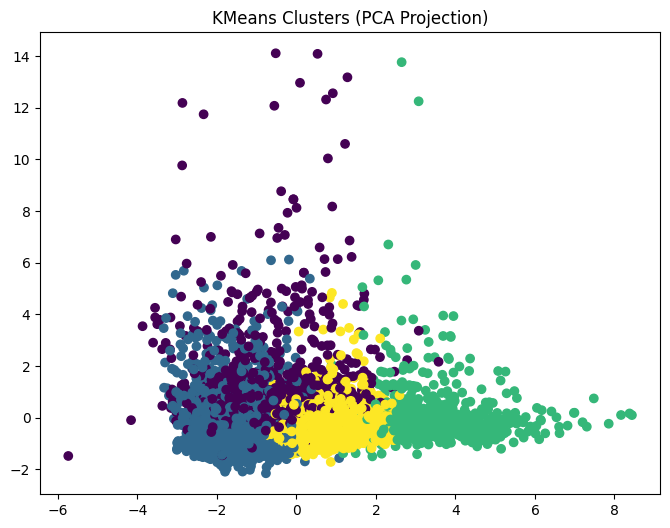

In [98]:
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=df["kmeans_cluster"], cmap='viridis')
plt.title("KMeans Clusters (PCA Projection)")
plt.show()

In [99]:
df['kmeans_cluster'].value_counts()

,count
kmeans_cluster,
1,1762
3,1326
0,864
2,644


### Cluster Interpretation

In [103]:
cluster_summary = df.groupby("kmeans_cluster")[[
    'danceability','energy','valence','tempo',
    'acousticness','instrumentalness','speechiness',
    'loudness'
]].mean()

cluster_summary

,danceability,energy,valence,tempo,acousticness,instrumentalness,speechiness,loudness
kmeans_cluster,,,,,,,,
0,0.457255,0.729144,0.687774,117.759595,0.509581,0.027875,0.132213,-7.968667
1,0.667421,0.745595,0.593298,120.967922,0.186965,0.026956,0.088664,-6.047853
2,0.449280,0.291484,0.443422,112.920376,0.870296,0.219905,0.063891,-13.990447
3,0.537281,0.522851,0.589834,114.055465,0.628114,0.015490,0.052684,-9.509778


### Final Interpreted Cluster Names.

| Cluster | Label           | Key Traits                 |
| ------- | --------------- | -------------------------- |
| 0       | Energetic Happy | High energy + high valence |
| 1       | Party           | High dance + high tempo    |
| 2       | Calm Acoustic   | Low energy + high acoustic |
| 3       | Balanced        | Moderate across all        |
